In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [21]:
#Data Loading
file_path = r"C:\\Users\\nopj2\\OneDrive\\Desktop\\Pranjal_Smart_Meter_Data_Analysis\\Daily_Billing_Load Profile.xlsx"

daily_df = pd.read_excel(file_path, sheet_name="Daily_profile")
billing_df = pd.read_excel(file_path, sheet_name="Billing_profile")
load_df = pd.read_excel(file_path, sheet_name="Load_profile")

In [22]:
print("DAILY PROFILE")
daily_df.info()

print("\nBILLING PROFILE")
billing_df.info()

print("\nLOAD PROFILE")
load_df.info()

DAILY PROFILE
<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   METER_NUMBER      234 non-null    str    
 1   READS             234 non-null    float64
 2   READ_DTTM         234 non-null    str    
 3   MEASUREMENT_TYPE  234 non-null    str    
dtypes: float64(1), str(3)
memory usage: 16.9 KB

BILLING PROFILE
<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ACCOUNT_NBR      8 non-null      int64  
 1   BADGE_ID         8 non-null      str    
 2   D1_USAGE_ID      8 non-null      int64  
 3   BO_STATUS_CD     8 non-null      str    
 4   START_DTTM       8 non-null      str    
 5   END_DTTM         8 non-null      str    
 6   CRE_DTTM         8 non-null      str    
 7   STATUS_UPD_DTTM  8 non-null      str

In [23]:
#Data overview
print("Daily Profile:", daily_df.shape)
print("Billing Profile:", billing_df.shape)
print("Load Profile:", load_df.shape)

Daily Profile: (234, 4)
Billing Profile: (8, 10)
Load Profile: (66822, 5)


In [24]:
#missing values
daily_df.isnull().sum()
billing_df.isnull().sum()
load_df.isnull().sum()

METER_NUMBER             0
READS                    0
READ_DTTM                0
MEASUREMENT_TYPE         0
MEASUREMENT_TYPE_NAME    0
dtype: int64

In [25]:
#Exploratory Data Analysis

daily_df['READ_DTTM'] = pd.to_datetime(daily_df['READ_DTTM'],dayfirst=True,errors='coerce')

load_df['READ_DTTM'] = pd.to_datetime(load_df['READ_DTTM'],dayfirst=True,errors='coerce')

In [26]:
daily_df['READ_DTTM'].head()
load_df['READ_DTTM'].head()

0   2025-08-25 00:00:00
1   2025-08-24 23:45:00
2   2025-08-24 23:30:00
3   2025-08-24 23:15:00
4   2025-08-24 23:00:00
Name: READ_DTTM, dtype: datetime64[us]

In [27]:
print("Daily Duplicates:", daily_df.duplicated().sum())
print("Billing Duplicates:", billing_df.duplicated().sum())
print("Load Duplicates:", load_df.duplicated().sum())

Daily Duplicates: 0
Billing Duplicates: 0
Load Duplicates: 0


In [28]:
daily_df.dtypes

METER_NUMBER                   str
READS                      float64
READ_DTTM           datetime64[us]
MEASUREMENT_TYPE               str
dtype: object

In [29]:
billing_df.dtypes

ACCOUNT_NBR          int64
BADGE_ID               str
D1_USAGE_ID          int64
BO_STATUS_CD           str
START_DTTM             str
END_DTTM               str
CRE_DTTM               str
STATUS_UPD_DTTM        str
KWH_READING          int64
KW_READING         float64
dtype: object

In [30]:

load_df.dtypes

METER_NUMBER                        str
READS                           float64
READ_DTTM                datetime64[us]
MEASUREMENT_TYPE                    str
MEASUREMENT_TYPE_NAME               str
dtype: object

In [31]:
date_columns = [
    'START_DTTM',
    'END_DTTM',
    'CRE_DTTM',
    'STATUS_UPD_DTTM'
]

for col in date_columns:
    billing_df[col] = pd.to_datetime(billing_df[col],dayfirst=True,errors='coerce')

billing_df.dtypes

C:\Users\nopj2\AppData\Local\Temp\ipykernel_26612\1817173192.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  billing_df[col] = pd.to_datetime(billing_df[col],dayfirst=True,errors='coerce')
C:\Users\nopj2\AppData\Local\Temp\ipykernel_26612\1817173192.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  billing_df[col] = pd.to_datetime(billing_df[col],dayfirst=True,errors='coerce')
C:\Users\nopj2\AppData\Local\Temp\ipykernel_26612\1817173192.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  billing_df[col] = pd.to_datetime(billing_df[col],dayfirst=True,errors='coerce')
C

ACCOUNT_NBR                int64
BADGE_ID                     str
D1_USAGE_ID                int64
BO_STATUS_CD                 str
START_DTTM         datetime64[s]
END_DTTM           datetime64[s]
CRE_DTTM           datetime64[s]
STATUS_UPD_DTTM    datetime64[s]
KWH_READING                int64
KW_READING               float64
dtype: object

In [32]:
print("Daily Zero Reads:",(daily_df['READS'] == 0).sum())

print("Load Zero Reads:",(load_df['READS'] == 0).sum())

Daily Zero Reads: 0
Load Zero Reads: 15966


In [33]:
load_df['MEASUREMENT_TYPE_NAME'].value_counts()

MEASUREMENT_TYPE_NAME
UP - Average Signal Strength    11137
UP - Meter Health Indicator     11137
UP - Average Current            11137
UP - Average Voltage            11137
UP - Block Load Energy KVAH     11137
UP - Block Load Energy KWH      11137
Name: count, dtype: int64

In [34]:
signal_df = load_df[
    load_df['MEASUREMENT_TYPE_NAME'] == 'UP - Average Signal Strength'
]

health_df = load_df[
    load_df['MEASUREMENT_TYPE_NAME'] == 'UP - Meter Health Indicator'
]

current_df = load_df[
    load_df['MEASUREMENT_TYPE_NAME'] == 'UP - Average Current'
]

voltage_df = load_df[
    load_df['MEASUREMENT_TYPE_NAME'] == 'UP - Average Voltage'
]

kvah_df = load_df[
    load_df['MEASUREMENT_TYPE_NAME'] == 'UP - Block Load Energy KVAH'
]

kwh_df = load_df[
    load_df['MEASUREMENT_TYPE_NAME'] == 'UP - Block Load Energy KWH'
]

In [35]:
print(len(signal_df))
print(len(health_df))
print(len(current_df))
print(len(voltage_df))
print(len(kvah_df))
print(len(kwh_df))

11137
11137
11137
11137
11137
11137


In [36]:
voltage_df['READS'].describe()

count    11137.000000
mean       246.074417
std         23.424783
min          0.000000
25%        246.010000
50%        248.590000
75%        250.800000
max        264.050000
Name: READS, dtype: float64

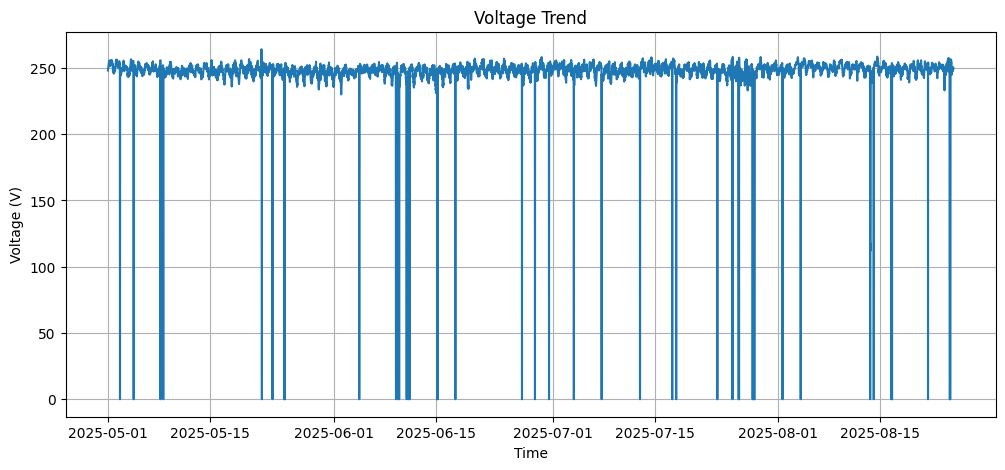

In [37]:
plt.figure(figsize=(12,5))

plt.plot(voltage_df['READ_DTTM'],voltage_df['READS'])

plt.title('Voltage Trend')
plt.xlabel('Time')
plt.ylabel('Voltage (V)')
plt.grid(True)

plt.show()

In [38]:
voltage_zeros = (voltage_df['READS'] == 0).sum()

print("Voltage Zero Readings:", voltage_zeros)

print("Percentage:",round(voltage_zeros / len(voltage_df) * 100,2))

Voltage Zero Readings: 96
Percentage: 0.86


In [39]:
current_df['READS'].describe()

count    11137.000000
mean         5.005812
std          2.805990
min          0.000000
25%          2.840000
50%          4.420000
75%          6.720000
max         18.690000
Name: READS, dtype: float64

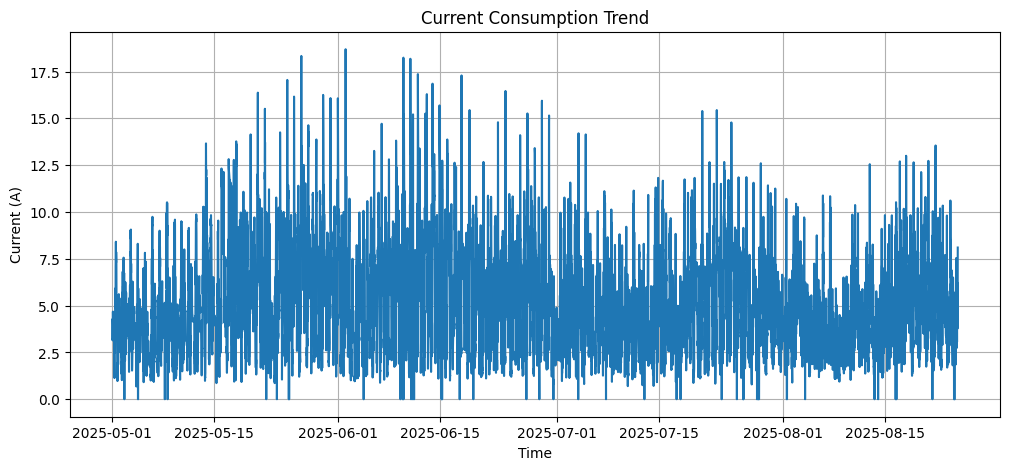

In [40]:
plt.figure(figsize=(12,5))

plt.plot(current_df['READ_DTTM'],current_df['READS'])

plt.title('Current Consumption Trend')
plt.xlabel('Time')
plt.ylabel('Current (A)')
plt.grid(True)

plt.show()

In [41]:
current_zeros = (current_df['READS'] == 0).sum()

print("Current Zero Readings:", current_zeros)

print("Percentage:",round(current_zeros / len(current_df) * 100, 2))

Current Zero Readings: 97
Percentage: 0.87


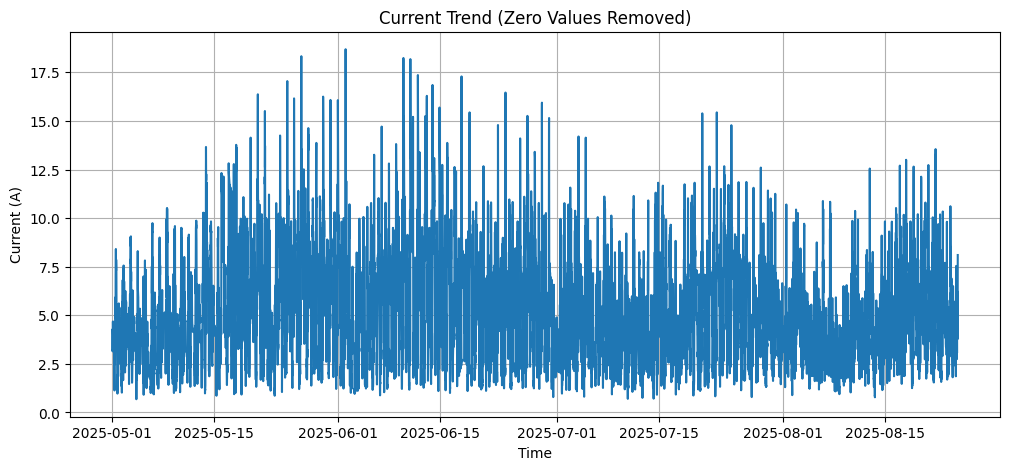

In [ ]:
current_clean = current_df[current_df['READS'] > 0]

plt.figure(figsize=(12,5))

plt.plot(
    current_clean['READ_DTTM'],
    current_clean['READS']
)

plt.title('Current Trend (Zero Values Removed)')
plt.xlabel('Time')
plt.ylabel('Current (A)')
plt.grid(True)

plt.show()

In [43]:
signal_df['READS'].describe()

count    11137.000000
mean        25.004669
std          2.800153
min          0.000000
25%         24.000000
50%         25.000000
75%         26.000000
max         29.000000
Name: READS, dtype: float64

In [44]:
health_df['READS'].value_counts()

READS
0.0      10834
32.0       301
128.0        2
Name: count, dtype: int64

In [ ]:
health_percent = (health_df['READS'].value_counts(normalize=True)* 100)

print(health_percent)

READS
0.0      97.279339
32.0      2.702703
128.0     0.017958
Name: proportion, dtype: float64


In [46]:
kwh_df['READS'].describe()

count    11137.000000
mean         0.193209
std          0.197519
min          0.000000
25%          0.005000
50%          0.150000
75%          0.298000
max          1.090000
Name: READS, dtype: float64

In [47]:
kwh_zeros = (kwh_df['READS'] == 0).sum()

print("KWH Zero Readings:", kwh_zeros)

print("Percentage:",round(kwh_zeros / len(kwh_df) * 100, 2))

KWH Zero Readings: 2474
Percentage: 22.21


In [ ]:
daily_kwh = (kwh_df.set_index('READ_DTTM').resample('D')['READS'].sum())

daily_kwh.head()

READ_DTTM
2025-05-01    12.468
2025-05-02    12.690
2025-05-03    13.312
2025-05-04    13.961
2025-05-05    11.737
Freq: D, Name: READS, dtype: float64

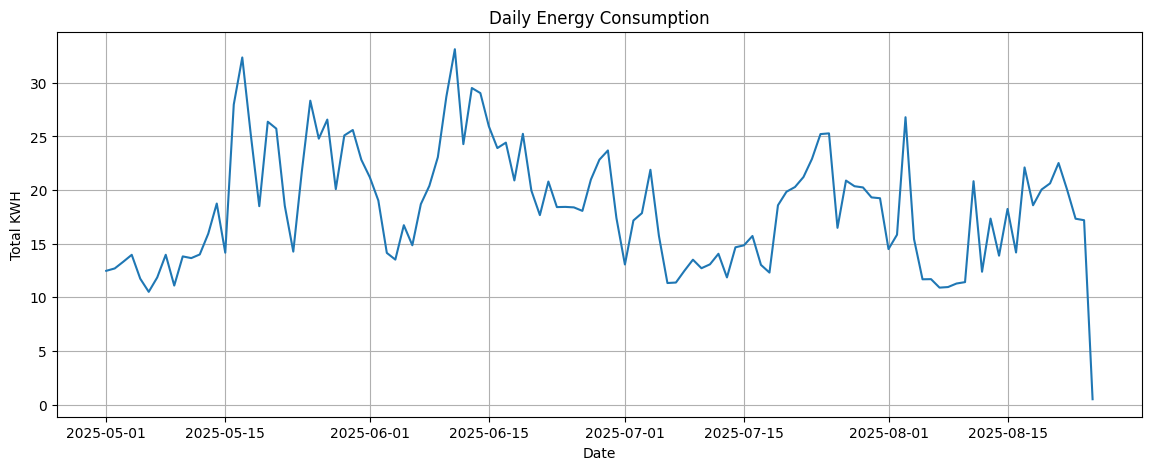

In [49]:
plt.figure(figsize=(14,5))

plt.plot(
    daily_kwh.index,
    daily_kwh.values
)

plt.title('Daily Energy Consumption')
plt.xlabel('Date')
plt.ylabel('Total KWH')
plt.grid(True)

plt.show()

In [ ]:
top_days = daily_kwh.sort_values(ascending=False).head(10)

top_days

READ_DTTM
2025-06-11    33.132
2025-05-17    32.363
2025-06-13    29.516
2025-06-14    29.041
2025-06-10    28.701
2025-05-25    28.336
2025-05-16    27.975
2025-08-03    26.791
2025-05-27    26.571
2025-05-20    26.372
Name: READS, dtype: float64

In [ ]:
low_days = daily_kwh.sort_values(ascending=True).head(10)

low_days

READ_DTTM
2025-08-25     0.495
2025-05-06    10.508
2025-08-07    10.901
2025-08-08    10.955
2025-05-09    11.094
2025-08-09    11.284
2025-07-06    11.330
2025-07-07    11.376
2025-08-10    11.414
2025-08-05    11.678
Name: READS, dtype: float64

In [52]:
#Monthly consumption

monthly_kwh = kwh_df.set_index('READ_DTTM').resample('ME')['READS'].sum()

monthly_kwh

READ_DTTM
2025-05-31    585.799
2025-06-30    643.265
2025-07-31    526.458
2025-08-31    396.251
Freq: ME, Name: READS, dtype: float64

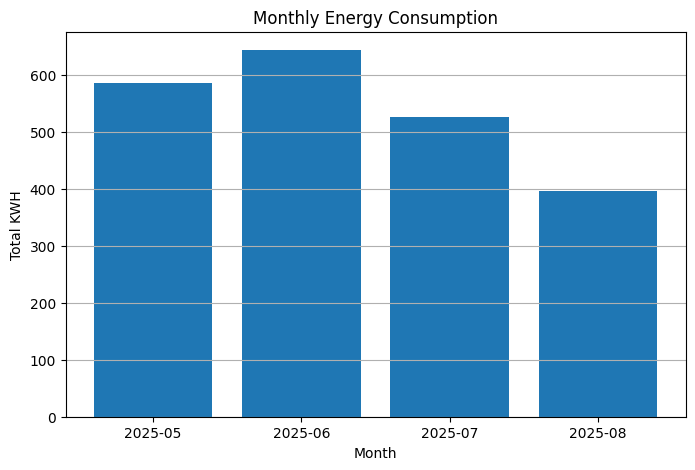

In [53]:
plt.figure(figsize=(8,5))

plt.bar(
    monthly_kwh.index.strftime('%Y-%m'),
    monthly_kwh.values
)

plt.title('Monthly Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Total KWH')

plt.grid(True, axis='y')

plt.show()

In [ ]:
voltage_current = (
    voltage_df[['READ_DTTM', 'READS']].merge(current_df[['READ_DTTM', 'READS']],on='READ_DTTM',suffixes=('_voltage', '_current'))
)

voltage_current.head()

,READ_DTTM,READS_voltage,READS_current
0,2025-08-25 00:00:00,249.43,8.10
1,2025-08-24 23:45:00,249.68,5.12
2,2025-08-24 23:30:00,250.32,5.24
3,2025-08-24 23:15:00,250.50,4.55
4,2025-08-24 23:00:00,249.22,3.77


In [55]:
voltage_current[['READS_voltage', 'READS_current']].corr()

,READS_voltage,READS_current
READS_voltage,1.000000,0.127871
READS_current,0.127871,1.000000


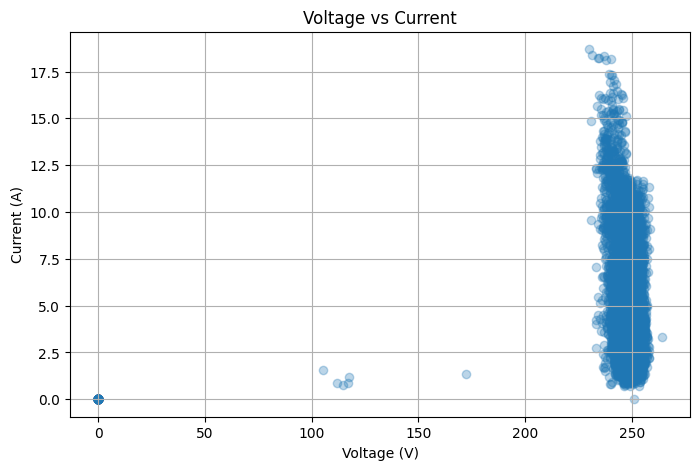

In [56]:
plt.figure(figsize=(8,5))

plt.scatter(
    voltage_current['READS_voltage'],
    voltage_current['READS_current'],
    alpha=0.3
)

plt.title('Voltage vs Current')
plt.xlabel('Voltage (V)')
plt.ylabel('Current (A)')
plt.grid(True)

plt.show()

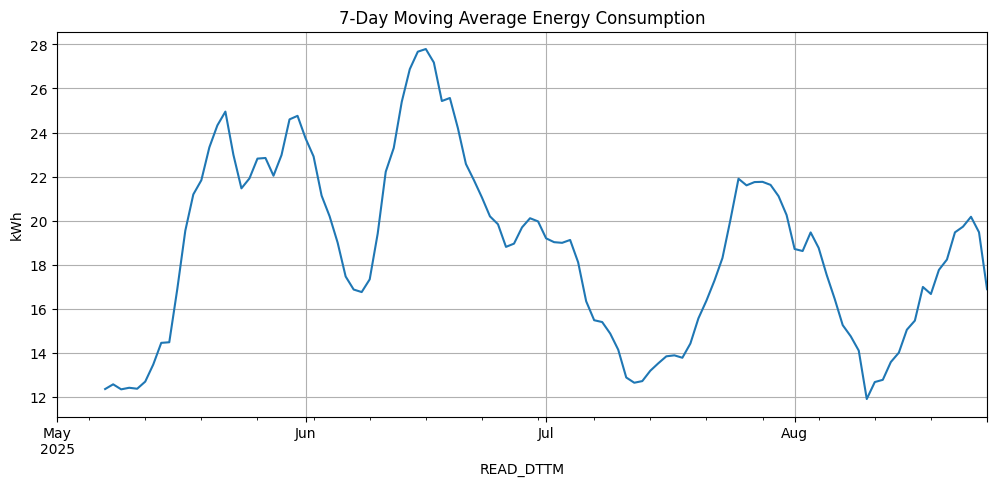

In [57]:
daily_kwh.rolling(7).mean().plot(figsize=(12,5))
plt.title("7-Day Moving Average Energy Consumption")
plt.ylabel("kWh")
plt.grid(True)
plt.show()

# Final Conclusions

## Data Quality
- Data types were successfully converted.
- Very few zero readings were found in Voltage (0.86%) and Current (0.87%).
- Overall data quality is good.

## Voltage Analysis
- Voltage remained stable around 250 V.
- Voltage fluctuations were minimal.

## Current Analysis
- Current consumption varied significantly over time.
- Maximum current observed was approximately 18.69 A.

## Health Signal Analysis
- Most readings were 0.
- Only a small number of readings had values 32 and 128.

## Energy Consumption Analysis
- June recorded the highest monthly energy consumption.
- August recorded the lowest monthly energy consumption.

## Correlation Analysis
- Correlation between Voltage and Current = 0.128.
- This indicates a very weak positive relationship.

## Overall Observation
- Energy usage is primarily driven by load behavior rather than voltage variation.
- The dataset appears suitable for further forecasting and consumption pattern analysis.
Voltage is highly stable (~250 V).
Current fluctuates according to load demand.
Health signal is mostly inactive (97.28% zeros).
kWh contains 22.21% zero readings.
June had the highest monthly consumption (643.27 kWh).
August had the lowest monthly consumption (396.25 kWh).
Peak daily consumption occurred on 2025-06-11 (33.13 kWh).
Voltage and Current have a very weak correlation (0.128).

# Recommendations and Future Enhancements

## Recommendations

Based on the analysis of the Daily Profile, Billing Profile, and Load Profile datasets, the following recommendations are proposed:

### 1. Improve Monitoring of Zero-Value Readings

The analysis identified a notable number of zero-value readings in the energy consumption data, accounting for approximately 22.21% of KWH records. While some of these values may represent genuine periods of no consumption, others could indicate communication failures, meter outages, or incomplete data capture.

It is recommended that automated validation rules be implemented to flag unusually long sequences of zero readings for further investigation.

### 2. Investigate Meter Health Events

The Meter Health Indicator showed that approximately 2.70% of observations contained warning-level conditions, while a small number of critical events were also detected.

Utility operators should investigate these occurrences to determine their root causes and prevent potential meter failures before they impact service reliability.

### 3. Monitor Peak Demand Periods

Energy consumption analysis revealed that the highest demand occurred between May and June, with peak daily consumption reaching 33.13 KWH.

Identifying and monitoring such peak-demand periods can help utilities optimize load distribution, reduce stress on infrastructure, and improve grid reliability.

### 4. Enhance Data Quality Controls

A significant drop in consumption was observed on 25 August 2025, which may indicate incomplete data collection or communication issues.

Implementing automated data quality checks and alert mechanisms would improve confidence in future analyses and operational decision-making.

### 5. Develop Real-Time Operational Dashboards

The analyzed parameters—including voltage, current, signal strength, energy consumption, and meter health—can be integrated into a centralized dashboard.

Such dashboards would provide utility operators with real-time visibility into system performance and enable faster response to abnormal conditions.

---

# Future Enhancements Using AI and Machine Learning

## 1. Intelligent Customer Interaction

An AI-powered customer assistant can be developed to provide consumers with personalized information regarding:

* Energy consumption trends
* Billing explanations
* Usage forecasts
* Energy-saving recommendations
* Service outage notifications

This would improve customer engagement while reducing support workload.

---

## 2. Anomaly Detection System

Machine learning models can continuously monitor smart meter data to detect unusual behavior.

Potential anomalies include:

* Sudden drops in consumption
* Abnormal voltage fluctuations
* Communication failures
* Suspicious meter activity

Algorithms such as Isolation Forest, Local Outlier Factor (LOF), and Autoencoders can be used to automate anomaly detection.

---

## 3. Predictive Maintenance of Smart Meters

Historical data including voltage, current, signal strength, and meter health indicators can be used to predict potential equipment failures.

Benefits include:

* Reduced downtime
* Lower maintenance costs
* Improved service reliability
* Better asset management

Predictive maintenance models can generate risk scores for each meter and prioritize maintenance activities accordingly.

---

## 4. Load Forecasting and Demand Prediction

Accurate forecasting of future electricity demand can help utilities improve operational planning.

Machine learning techniques such as:

* XGBoost
* Random Forest
* LSTM Neural Networks
* Facebook Prophet

can be used to predict future consumption based on historical usage patterns, seasonal trends, and environmental factors.

---

## 5. Energy Theft Detection

Smart meter data can be analyzed to identify suspicious consumption patterns that may indicate energy theft.

Potential indicators include:

* Unexpected consumption drops
* Irregular usage behavior
* Significant deviations from historical patterns
* Abnormal consumption compared to similar consumers

Machine learning classification models can assist utilities in prioritizing high-risk cases for inspection.

---

## 6. Personalized Energy Efficiency Recommendations

Consumer-specific analytics can be used to provide customized recommendations for reducing electricity consumption.

Examples include:

* Identifying inefficient usage patterns
* Recommending optimal appliance usage schedules
* Comparing consumption against similar households
* Estimating potential cost savings

This can improve customer satisfaction while supporting energy conservation goals.

---

## 7. Fault Detection and Diagnostics

Advanced analytics can automatically detect and diagnose issues such as:

* Meter malfunctions
* Communication failures
* Voltage abnormalities
* Sensor errors

Automated fault classification systems can significantly reduce troubleshooting time and improve operational efficiency.

---

## 8. Real-Time Smart Grid Analytics Platform

A future smart grid platform can integrate:

Smart Meters → Data Ingestion Layer → Real-Time Analytics Engine → AI/ML Models → Dashboards & Alerts

Such a platform would enable:

* Live monitoring of energy consumption
* Automated anomaly detection
* Demand forecasting
* Predictive maintenance
* Customer engagement services
* Intelligent operational decision-making

This would transform traditional metering infrastructure into a data-driven, intelligent energy management ecosystem.

## Conclusion

The analysis demonstrates that smart meter data provides significant opportunities for operational optimization, predictive analytics, and enhanced customer services. By combining traditional data analytics with AI and Machine Learning techniques, utilities can improve reliability, reduce operational costs, detect abnormal behavior more effectively, and deliver a superior customer experience while supporting the development of smarter and more efficient energy networks.
